In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

In [14]:
# ================================
# 1. LEITURA E PRÉ-PROCESSAMENTO
# ================================

# Ajuste o separador se necessário (ex: sep=';')
df = pd.read_csv('https://raw.githubusercontent.com/Sandrocamargo/data-science/refs/heads/main/datasets/CID-RS.txt', sep=';', header=0)

# Define primeira coluna como índice (doenças)
df.set_index(df.columns[0], inplace=True)

# Remove última linha e última coluna (totais)
df = df.iloc[:-1, :-1]

# Converte para numérico (caso tenha strings)
df = df.apply(pd.to_numeric, errors='coerce')

# Remove possíveis NaNs
df = df.dropna()

print("Shape final:", df.shape)
df.head()

Shape final: (19, 19)


,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
CID,,,,,,,,,,,,,,,,,,,
CID-I,3883,50891,47656,47522,43247,44689,43296,43433,44843,47014,46379,46019,49018,70299,112517,56757,48772,58560,48816
CID-II,3938,50101,51620,51867,52086,55219,57133,61784,62234,62466,64751,64164,68618,60918,61781,69737,72224,75329,74211
CID-III,295,5550,5395,5979,5878,6216,6326,6416,6759,6776,7108,6761,6832,5907,6300,6864,7092,7640,7224
CID-IV,1074,19271,19148,18554,17364,16836,15573,16493,15558,14669,13840,13754,13458,10949,11027,12305,12768,13247,13222
CID-V,1482,25128,31034,33790,35753,34693,36943,38117,36561,35729,37682,39409,41609,33807,34334,37561,41277,40817,39332


In [3]:
# ================================
# 2. NORMALIZAÇÃO
# ================================

scaler = StandardScaler()

# Para clustering de doenças (linhas)
X_diseases = scaler.fit_transform(df.values)

# Para clustering de anos (colunas)
X_years = scaler.fit_transform(df.T.values)

In [4]:
# ================================
# 3. CLUSTERING - DOENÇAS
# ================================

print("\n=== CLUSTERING DE DOENÇAS ===")

# KMeans
kmeans_d = KMeans(n_clusters=3, random_state=42)
labels_kmeans_d = kmeans_d.fit_predict(X_diseases)

# Hierarchical
agglo_d = AgglomerativeClustering(n_clusters=3)
labels_agglo_d = agglo_d.fit_predict(X_diseases)

# DBSCAN
dbscan_d = DBSCAN(eps=1.5, min_samples=2)
labels_dbscan_d = dbscan_d.fit_predict(X_diseases)

# Adiciona resultados ao DataFrame
df_clusters_d = df.copy()
df_clusters_d['KMeans'] = labels_kmeans_d
df_clusters_d['Agglomerative'] = labels_agglo_d
df_clusters_d['DBSCAN'] = labels_dbscan_d

df_clusters_d.head(30)


=== CLUSTERING DE DOENÇAS ===


,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,...,2019,2020,2021,2022,2023,2024,2025,KMeans,Agglomerative,DBSCAN
CID,,,,,,,,,,,,,,,,,,,,,
CID-I,3883,50891,47656,47522,43247,44689,43296,43433,44843,47014,...,49018,70299,112517,56757,48772,58560,48816,2,0,-1
CID-II,3938,50101,51620,51867,52086,55219,57133,61784,62234,62466,...,68618,60918,61781,69737,72224,75329,74211,2,0,0
CID-III,295,5550,5395,5979,5878,6216,6326,6416,6759,6776,...,6832,5907,6300,6864,7092,7640,7224,0,1,1
CID-IV,1074,19271,19148,18554,17364,16836,15573,16493,15558,14669,...,13458,10949,11027,12305,12768,13247,13222,0,1,1
CID-V,1482,25128,31034,33790,35753,34693,36943,38117,36561,35729,...,41609,33807,34334,37561,41277,40817,39332,2,0,-1
CID-VI,1273,17113,17048,16506,16990,17062,17626,18084,17619,16332,...,16670,13139,13389,16602,18088,17456,16803,0,1,1
CID-VII,112,2752,3009,3279,3193,3223,3627,4418,5012,5647,...,6847,4515,6370,7683,6852,7265,6959,0,1,1
CID-VIII,109,1264,1260,1436,1375,1352,1372,1609,1722,1659,...,1856,881,941,1576,1753,2121,2275,0,1,1
CID-IX,6894,95268,95458,93853,91325,89696,93064,97068,93788,93218,...,93378,79963,80207,89675,92685,96763,91371,1,2,-1


In [5]:
# ================================
# 4. CLUSTERING - ANOS
# ================================

print("\n=== CLUSTERING DE ANOS ===")

years = df.columns

# KMeans
kmeans_y = KMeans(n_clusters=3, random_state=42)
labels_kmeans_y = kmeans_y.fit_predict(X_years)

# Hierarchical
agglo_y = AgglomerativeClustering(n_clusters=3)
labels_agglo_y = agglo_y.fit_predict(X_years)

# DBSCAN
dbscan_y = DBSCAN(eps=1.5, min_samples=2)
labels_dbscan_y = dbscan_y.fit_predict(X_years)

df_years = pd.DataFrame({
    'Year': years,
    'KMeans': labels_kmeans_y,
    'Agglomerative': labels_agglo_y,
    'DBSCAN': labels_dbscan_y
})

print(df_years)



=== CLUSTERING DE ANOS ===
    Year  KMeans  Agglomerative  DBSCAN
0   2007       1              1      -1
1   2008       2              0       0
2   2009       2              0       0
3   2010       2              0       0
4   2011       2              0       0
5   2012       2              0       0
6   2013       2              0       0
7   2014       0              2       0
8   2015       0              2       0
9   2016       0              2       0
10  2017       0              2       0
11  2018       0              2       0
12  2019       0              2       0
13  2020       2              0      -1
14  2021       2              0      -1
15  2022       0              2       0
16  2023       0              2      -1
17  2024       0              2       1
18  2025       0              2       1


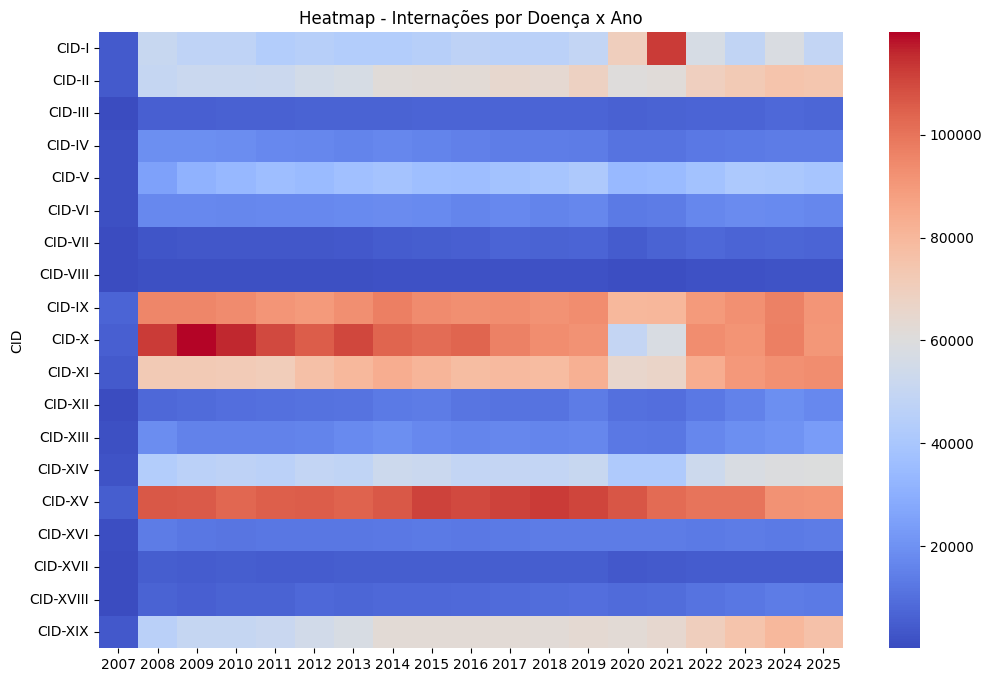

In [6]:
# ================================
# 5. VISUALIZAÇÃO - HEATMAP
# ================================

plt.figure(figsize=(12, 8))
sns.heatmap(df, cmap='coolwarm')
plt.title("Heatmap - Internações por Doença x Ano")
plt.show()

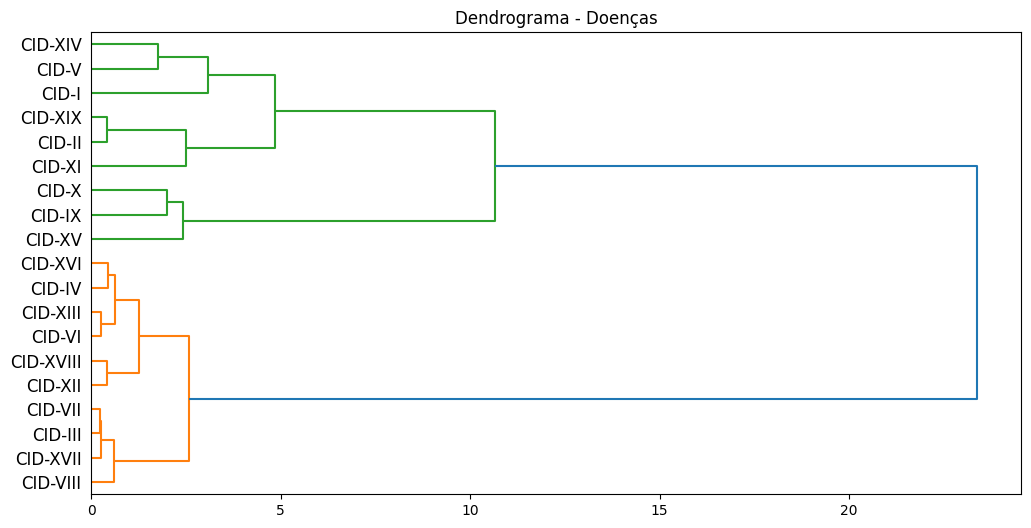

In [7]:
# ================================
# 6. DENDROGRAMA (DOENÇAS)
# ================================

linked = linkage(X_diseases, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked,
           labels=df.index,
           orientation='right')
plt.title("Dendrograma - Doenças")
plt.show()

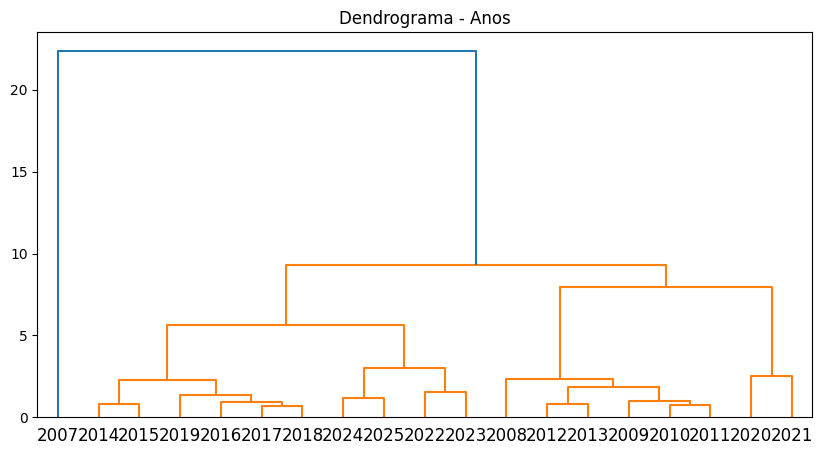

In [13]:
# ================================
# 7. DENDROGRAMA (ANOS)
# ================================

linked_years = linkage(X_years, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked_years,
           labels=years)
plt.title("Dendrograma - Anos")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# (Opcional, mas recomendado) normalizar os dados
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Converter de volta para DataFrame (mantendo labels)
import pandas as pd
df_scaled = pd.DataFrame(df_scaled, index=df.index, columns=df.columns)

# Clustermap (heatmap + dendrogramas)
sns.clustermap(
    df_scaled,
    cmap='coolwarm',     # 🔴 alto | 🔵 baixo
    method='ward',
    metric='euclidean',
    figsize=(12, 10),
    linewidths=0.1
)

plt.suptitle("Heatmap com Dendrogramas - Internações por Doença x Ano", y=1.02)
plt.show()